In [36]:
import numpy as np                           # arrays and linear algebra
import pandas as pd                          # tables
import matplotlib.pyplot as plt 

from sklearn import decomposition            # PCA
from sklearn.preprocessing import StandardScaler, scale   # scaling [WEATHER][PCA]
from sklearn.decomposition import PCA        # same class as decomposition.PCA

np.set_printoptions(suppress=True)


In [37]:
cohort = pd.read_csv("../data/clean/cohort_cleaned.csv")
cohort_numeric = cohort.iloc[:, 3:]
cohort_numeric.head()

,durationInMs,deepSleepDurationInMs,lightSleepDurationInMs,remSleepInMs,awakeDurationInMs,overallSleepScore,breathsPerMinute_mean,breathsPerMinute_std,breathsPerMinute_min,breathsPerMinute_max,...,restingHeartRateInBeatsPerMinute,minHeartRateInBeatsPerMinute,maxHeartRateInBeatsPerMinute,averageStressInStressLevel,maxStressInStressLevel,steps,activeKilocalories,bmrKilocalories,moderateIntensityDurationInMs,vigorousIntensityDurationInMs
0,29340000,3540000.0,19800000.0,6000000.0,60000.0,78.0,17.341388,2.072629,8.00,23.00,...,51.0,48.0,107.0,43.0,99.0,2825,126,2333,0,0
1,23340000,3660000.0,17100000.0,2580000.0,300000.0,73.0,17.201802,1.916917,10.83,22.58,...,50.0,46.0,120.0,41.0,99.0,8040,628,2339,1440000,120000
2,20940000,4200000.0,13140000.0,3600000.0,60000.0,76.0,15.170688,1.796894,7.50,19.41,...,48.0,45.0,103.0,40.0,98.0,3394,160,2333,0,0
3,21240000,3660000.0,14880000.0,2700000.0,1680000.0,60.0,18.227795,1.968694,11.66,23.41,...,53.0,45.0,109.0,53.0,98.0,5823,275,2333,0,0
4,24000000,2700000.0,17160000.0,2580000.0,180000.0,75.0,15.627893,2.401607,7.58,21.08,...,50.0,48.0,106.0,37.0,95.0,5947,250,2333,0,0


In [38]:
cohort_scaled = StandardScaler().fit_transform(cohort_numeric)
cohort_scaled = pd.DataFrame(cohort_scaled, columns=cohort_numeric.columns)
cohort_scaled.head()
cohort_scaled.to_csv("../data/clean/pca/pca_scaled_data.csv")

In [39]:
pca = decomposition.PCA()
pca.fit(cohort_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [40]:
# Share of the total variance carried by each PC
explained_variance = pca.explained_variance_ratio_
print("explained variance ratio:", np.round(explained_variance, 4))

# Running total, and the first k that reaches a target
cumulative = np.cumsum(explained_variance)
print("cumulative              :", np.round(cumulative, 4))
k_95 = int(np.searchsorted(cumulative, 0.95)) + 1      # +1 because counting starts at 0  [SVD]
print("components needed for 95%:", k_95)

explained variance ratio: [0.2673 0.1354 0.1079 0.0803 0.0568 0.0512 0.0474 0.0403 0.0351 0.0347
 0.0263 0.0254 0.022  0.0167 0.0107 0.0105 0.0088 0.0077 0.006  0.0049
 0.0044 0.0001]
cumulative              : [0.2673 0.4026 0.5105 0.5909 0.6477 0.6989 0.7463 0.7866 0.8218 0.8565
 0.8827 0.9081 0.9302 0.9469 0.9575 0.968  0.9769 0.9846 0.9906 0.9955
 0.9999 1.    ]
components needed for 95%: 15


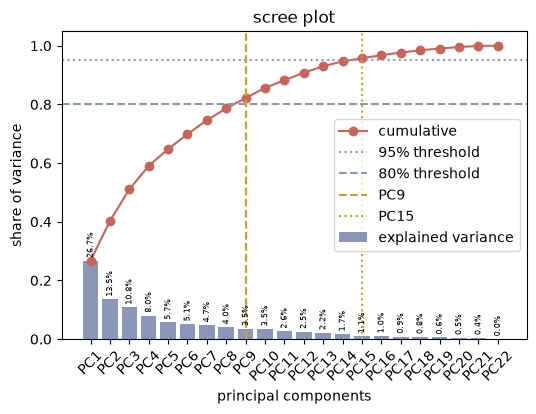

In [41]:
# Scree plot: bars = each PC's share, line = running total
pcs = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10", "PC11",
       "PC12", "PC13", "PC14", "PC15", "PC16", "PC17", "PC18", "PC19", "PC20", "PC21", "PC22"]
plt.figure(figsize=(6, 4))
bars = plt.bar(pcs, explained_variance, color="#8A97B8", label="explained variance")
plt.bar_label(bars, labels=[f"{v*100:.1f}%" for v in explained_variance], fontsize=6, rotation=90, padding=2)
plt.plot(pcs, cumulative, marker="o", color="#C9645A", label="cumulative")
plt.xlabel("principal components")
plt.xticks(rotation=45)
plt.ylabel("share of variance")
plt.title("scree plot")
plt.axhline(y=0.95, color="#8A97B8", linestyle=":", label="95% threshold")
plt.axhline(y=0.80, color="#8A97B8", linestyle="--", label="80% threshold")
plt.axvline(x=8, color="#C9A227", linestyle="--", label="PC9")
plt.axvline(x=14, color="#C9A227", linestyle=":", label="PC15")
plt.legend()
plt.savefig("../images/pca/scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=["PC1", "PC2", "PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10", "PC11","PC12","PC13","PC14","PC15","PC16","PC17","PC18","PC19","PC20","PC21","PC22"], index=cohort_scaled.columns)
print(df_loadings.round(2), "\n")

                                   PC1   PC2   PC3   PC4   PC5   PC6   PC7  \
durationInMs                     -0.09 -0.21  0.56  0.07 -0.02  0.18 -0.05   
deepSleepDurationInMs            -0.07  0.05  0.06 -0.37  0.43  0.12  0.02   
lightSleepDurationInMs           -0.00 -0.17  0.45  0.30 -0.25  0.23 -0.06   
remSleepInMs                     -0.14 -0.21  0.40 -0.14  0.11 -0.11 -0.01   
awakeDurationInMs                 0.05 -0.05 -0.08  0.43 -0.21  0.10 -0.35   
overallSleepScore                -0.27 -0.08  0.34 -0.25  0.16 -0.07  0.04   
breathsPerMinute_mean             0.29 -0.26 -0.02 -0.00  0.03 -0.26  0.12   
breathsPerMinute_std              0.07 -0.06  0.00  0.47  0.60 -0.06  0.11   
breathsPerMinute_min              0.22 -0.18 -0.04 -0.33 -0.29 -0.20  0.10   
breathsPerMinute_max              0.26 -0.24  0.03  0.20  0.31 -0.22  0.17   
lastNightAvg                     -0.31  0.21 -0.02  0.13 -0.05 -0.10  0.06   
lastNight5MinHigh                -0.29  0.18  0.00  0.22  0.07 -

In [43]:
pc1_sorted = df_loadings.iloc[:,0].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC1 loadings sorted by magnitude:\n\n",pc1_sorted)

PC1 loadings sorted by magnitude:

 restingHeartRateInBeatsPerMinute    0.350945
minHeartRateInBeatsPerMinute        0.324181
lastNightAvg                       -0.314741
lastNight5MinHigh                  -0.290828
breathsPerMinute_mean               0.288281
activeKilocalories                  0.277258
overallSleepScore                  -0.265957
averageStressInStressLevel          0.264469
breathsPerMinute_max                0.259971
breathsPerMinute_min                0.222163
moderateIntensityDurationInMs       0.203657
maxHeartRateInBeatsPerMinute        0.188552
vigorousIntensityDurationInMs       0.182226
remSleepInMs                       -0.138605
maxStressInStressLevel              0.107203
bmrKilocalories                     0.090030
durationInMs                       -0.086564
deepSleepDurationInMs              -0.073191
breathsPerMinute_std                0.073021
awakeDurationInMs                   0.054484
steps                               0.017388
lightSleepDurationI

In [44]:
pc2_sorted = df_loadings.iloc[:,1].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC2 loadings sorted by magnitude:\n\n",pc2_sorted)

PC2 loadings sorted by magnitude:

 steps                               0.345095
maxHeartRateInBeatsPerMinute        0.339385
activeKilocalories                  0.309061
vigorousIntensityDurationInMs       0.304100
maxStressInStressLevel              0.290221
breathsPerMinute_mean              -0.256637
breathsPerMinute_max               -0.244183
moderateIntensityDurationInMs       0.218856
durationInMs                       -0.212373
remSleepInMs                       -0.211379
lastNightAvg                        0.206566
breathsPerMinute_min               -0.183508
lastNight5MinHigh                   0.181939
lightSleepDurationInMs             -0.168769
minHeartRateInBeatsPerMinute       -0.163623
averageStressInStressLevel          0.143003
restingHeartRateInBeatsPerMinute   -0.129932
bmrKilocalories                     0.115455
overallSleepScore                  -0.082971
breathsPerMinute_std               -0.055038
deepSleepDurationInMs               0.051320
awakeDurationInMs  

In [45]:
pc3_sorted = df_loadings.iloc[:,2].sort_values(key=lambda s: s.abs(), ascending=False)
print("PC3 loadings sorted by magnitude:\n\n",pc3_sorted)

PC3 loadings sorted by magnitude:

 durationInMs                        0.555370
lightSleepDurationInMs              0.449128
remSleepInMs                        0.397453
overallSleepScore                   0.338161
maxHeartRateInBeatsPerMinute        0.228577
vigorousIntensityDurationInMs       0.227064
moderateIntensityDurationInMs       0.190415
activeKilocalories                  0.161673
maxStressInStressLevel              0.140218
steps                               0.090126
bmrKilocalories                    -0.087258
awakeDurationInMs                  -0.080932
deepSleepDurationInMs               0.057297
breathsPerMinute_min               -0.039254
averageStressInStressLevel          0.038345
minHeartRateInBeatsPerMinute        0.036743
breathsPerMinute_max                0.025364
lastNightAvg                       -0.023553
breathsPerMinute_mean              -0.017988
restingHeartRateInBeatsPerMinute    0.013992
lastNight5MinHigh                   0.003296
breathsPerMinute_st

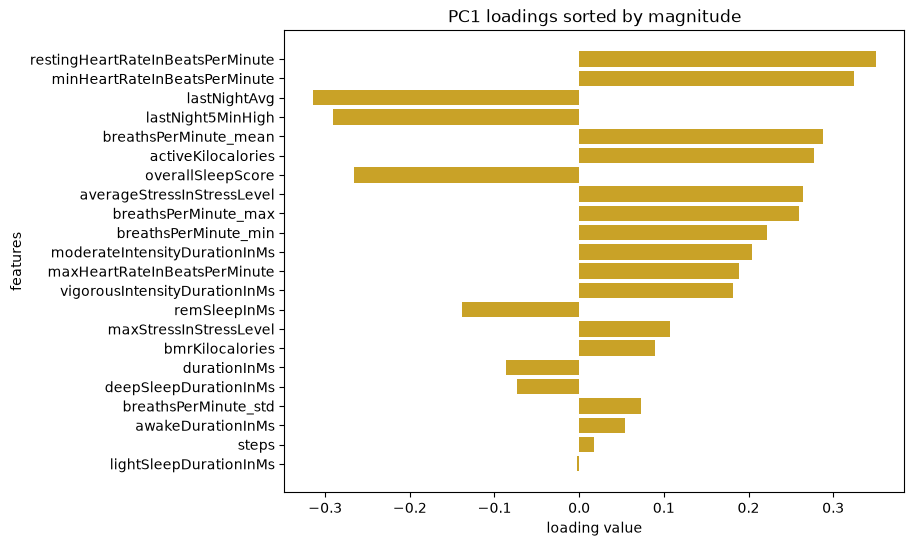

In [46]:
plt.figure(figsize=(8, 6))
plt.barh(pc1_sorted.index,pc1_sorted.values, color="#C9A227", label="PC1 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC1 loadings sorted by magnitude")
plt.savefig("../images/pca/pc1_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

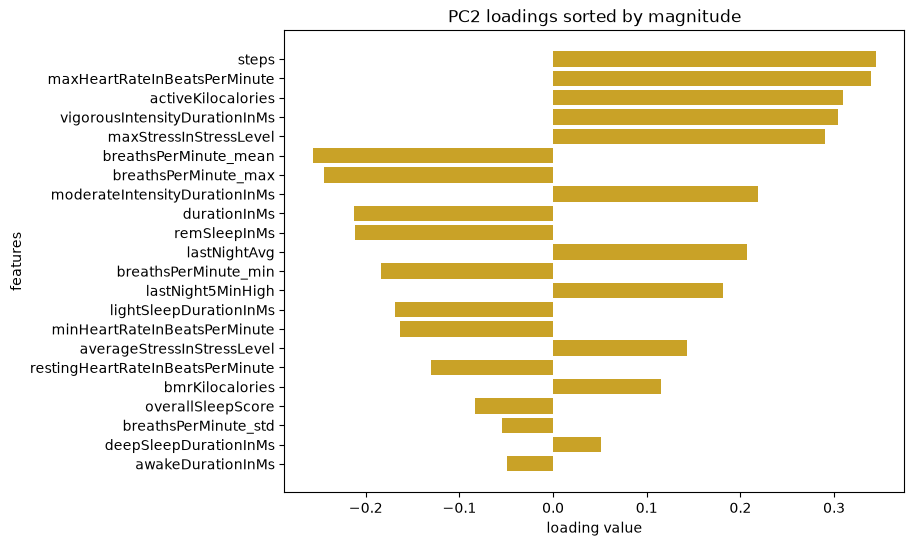

In [47]:
plt.figure(figsize=(8,6))
plt.barh(pc2_sorted.index,pc2_sorted.values, color="#C9A227", label="PC2 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC2 loadings sorted by magnitude")
plt.savefig("../images/pca/pc2_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

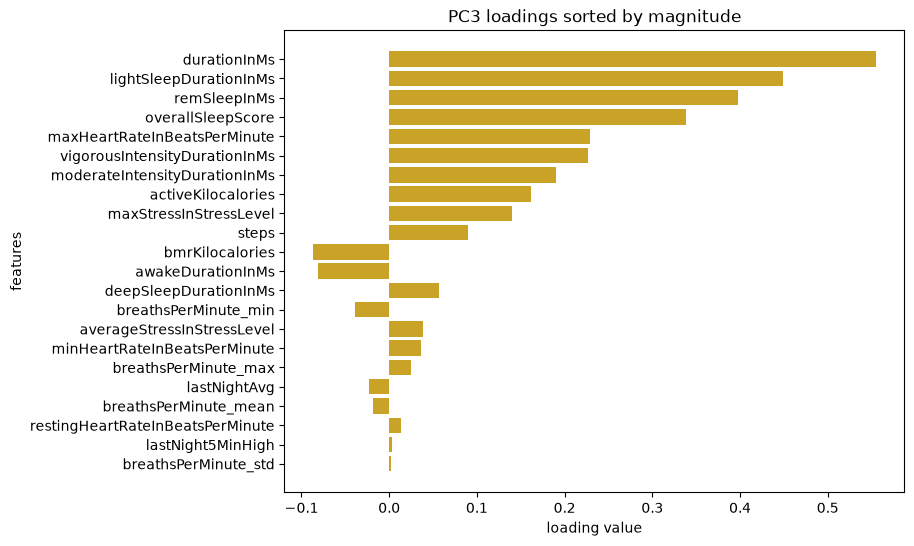

In [48]:
plt.figure(figsize=(8,6))
plt.barh(pc3_sorted.index,pc3_sorted.values, color="#C9A227", label="PC3 loadings")
plt.gca().invert_yaxis()  # largest loading on top
plt.xlabel("loading value")
plt.ylabel("features")
plt.title("PC3 loadings sorted by magnitude")
plt.savefig("../images/pca/pc3_loadings.png", dpi=150, bbox_inches="tight")
plt.show()

In [49]:
Xd = cohort_scaled                            # (18728, 22), standardized to match the sklearn PCA
n = Xd.shape[0]                               # number of samples (nights)

Uf, Sf, Vtf = np.linalg.svd(Xd, full_matrices=False)       # 1. economy SVD (scaled data is already centered)
print("U:", Uf.shape, "  S:", Sf.shape, "  Vt:", Vtf.shape)

var_pc = Sf**2 / (n - 1)                      # 2. variance along each PC = eigenvalues

C = (Xd.T @ Xd) / (n - 1)                     # 3. the covariance matrix, 22 x 22
eig = np.sort(np.linalg.eigvalsh(C))[::-1]    # its eigenvalues, sorted biggest first

print("\n\nvariance from the SVD       :", np.round(var_pc, 4))
print("\n\neigenvalues of the covariance:", np.round(eig, 4))
print("\n\nidentical:", np.allclose(var_pc, eig))

pct = 100 * var_pc / var_pc.sum()             # 4. percent of variance (matches explained_variance_ratio_)
print("\n\npercent of variance:", np.round(pct, 2))

U: (18728, 22)   S: (22,)   Vt: (22, 22)


variance from the SVD       : [5.8799 2.9787 2.3734 1.7678 1.2495 1.1264 1.0435 0.8875 0.7732 0.7633
 0.5776 0.5596 0.4846 0.3669 0.2353 0.2305 0.1944 0.1702 0.1313 0.1082
 0.0963 0.0031]


eigenvalues of the covariance: [5.8799 2.9787 2.3734 1.7678 1.2495 1.1264 1.0435 0.8875 0.7732 0.7633
 0.5776 0.5596 0.4846 0.3669 0.2353 0.2305 0.1944 0.1702 0.1313 0.1082
 0.0963 0.0031]


identical: True


percent of variance: [26.73 13.54 10.79  8.03  5.68  5.12  4.74  4.03  3.51  3.47  2.63  2.54
  2.2   1.67  1.07  1.05  0.88  0.77  0.6   0.49  0.44  0.01]
